# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

c:\Users\alh55\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

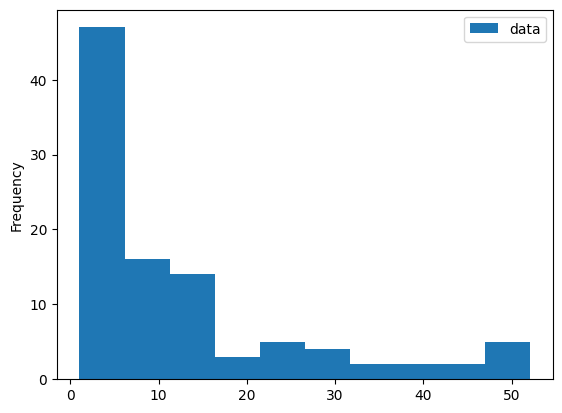

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

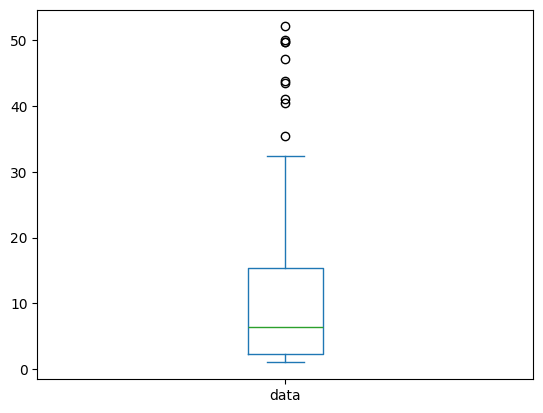

In [3]:
df.plot.box()

In [ ]:
'''
# pros and cons of these two reps
Histogram: 
pro: easy to see the price with most distribution, as well as where price starts to taper of
cons: Hard to get estimate of where the majority falls by just glancing, 
doesnt answer question how much more the expensive drugs cost at first glance if comparing to median

Boxplot
pro: easy to see where majority is and where the outliers are so you can see difference in price
cons: Hard to determine actual amount of each and lacks precision 

# Which to choose
Between these two graphs to determine how much more expensive drugs tend to cost I would choose the box graph.
It shows the spread and is easier to determine the range from the median.

# How would I mod
Easiest mod to make would be show prices at the points on the box plot so you can quickly calculate differences
'''

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [3]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)
csv_file = os.path.join(path, "creditcard.csv")

df_fraud = pd.read_csv(csv_file)


Path to dataset files: C:\Users\alh55\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [58]:
# Dataset 2
path2 = kagglehub.dataset_download("danb91/covid-ppp-loan-data-with-fraud-examples")
print("Path to dataset files:", path2)
files2 = os.listdir(path2)

csv_file2 = os.path.join(path2, files2[2])


df_loan = pd.read_csv(csv_file2)


Path to dataset files: C:\Users\alh55\.cache\kagglehub\datasets\danb91\covid-ppp-loan-data-with-fraud-examples\versions\1


<Axes: >

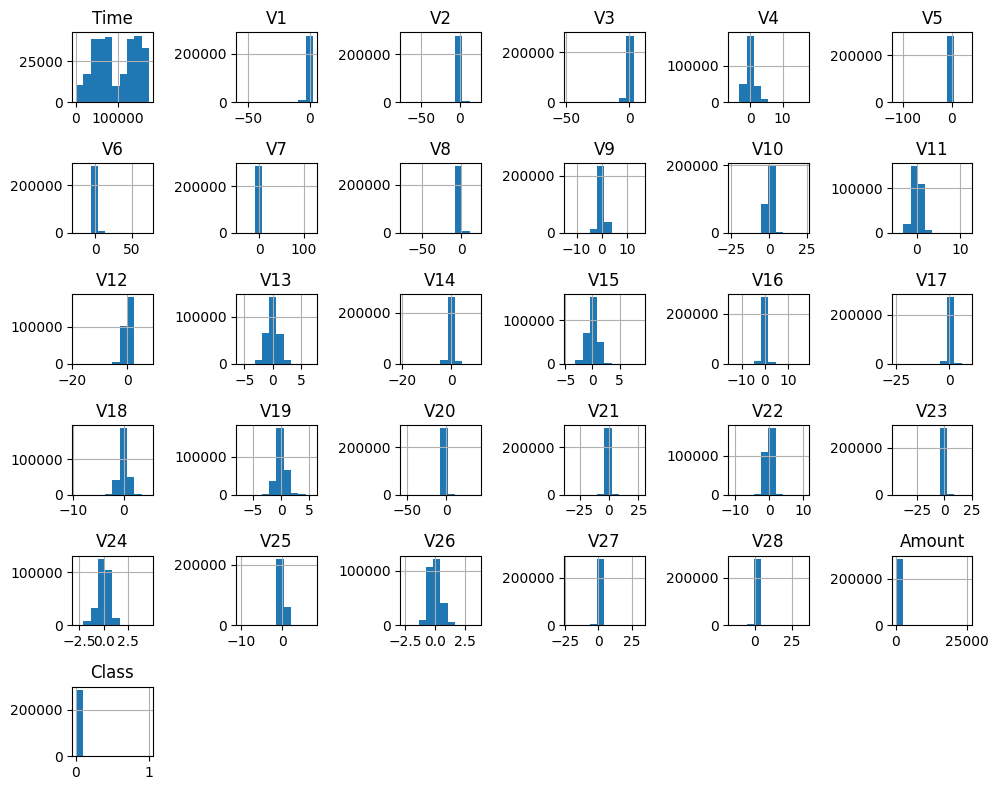

In [ ]:
# Histogram of data + variants for ea col
df_fraud.hist(figsize=(10,8))
plt.tight_layout()


<Axes: >

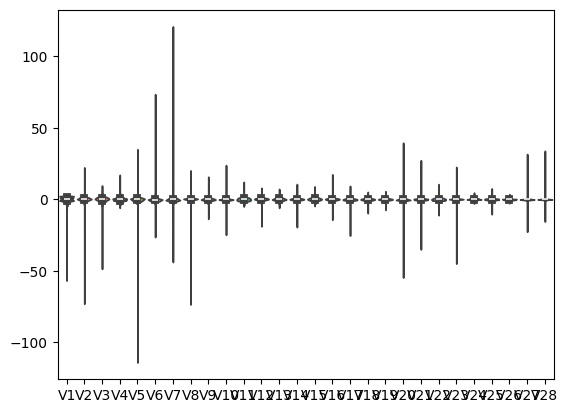

In [ ]:
# Plot of all V columns

sns.violinplot(data=df_fraud.drop(['Time','Amount','Class'],axis=1))

<Axes: ylabel='Time'>

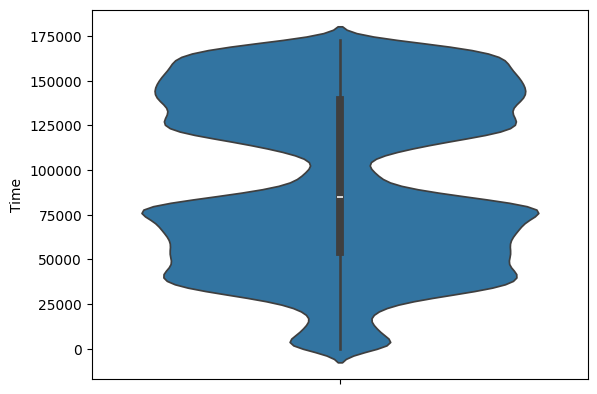

In [64]:
sns.violinplot(data=df_fraud['Time'])

<Axes: ylabel='Amount'>

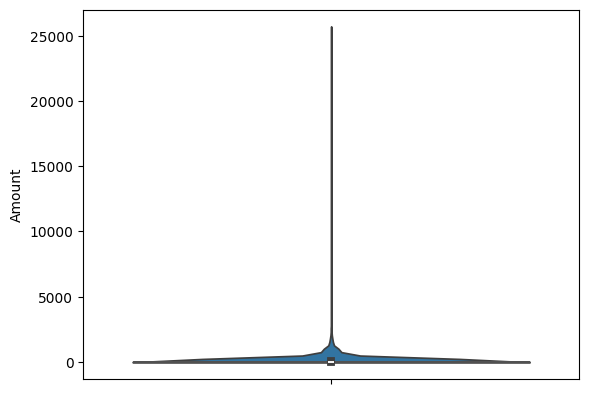

In [ ]:
sns.violinplot(data=df_fraud['Amount'])


<Axes: ylabel='Class'>

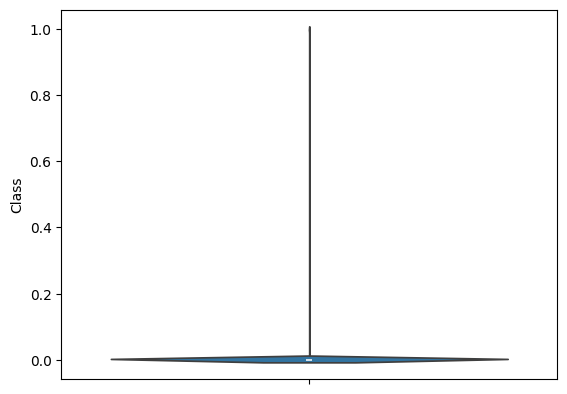

In [ ]:
# Class column is binary so chart will be hard to determine

sns.violinplot(data=df_fraud['Class'])

C:\Users\alh55\AppData\Local\Temp\ipykernel_28004\1200937732.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


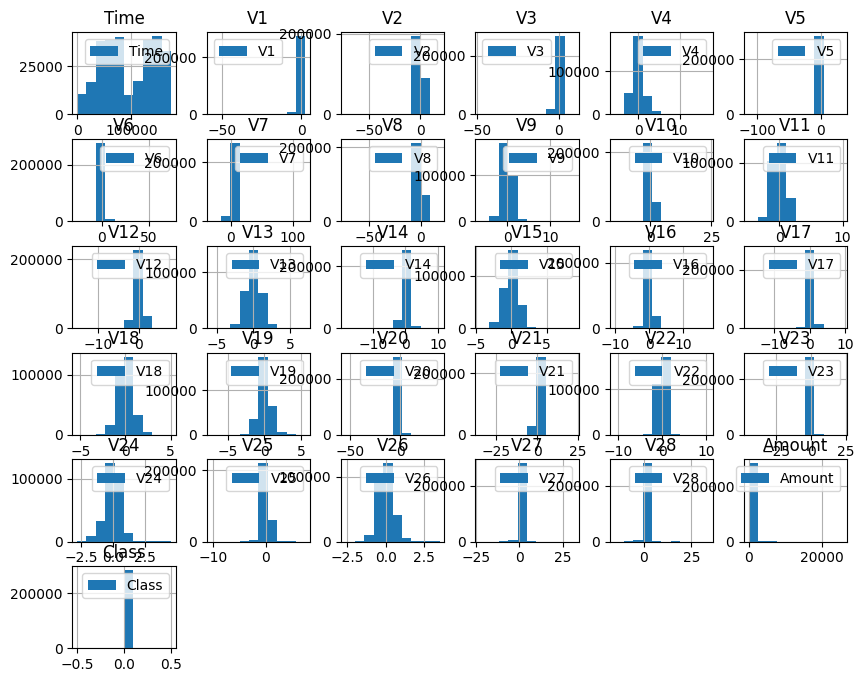

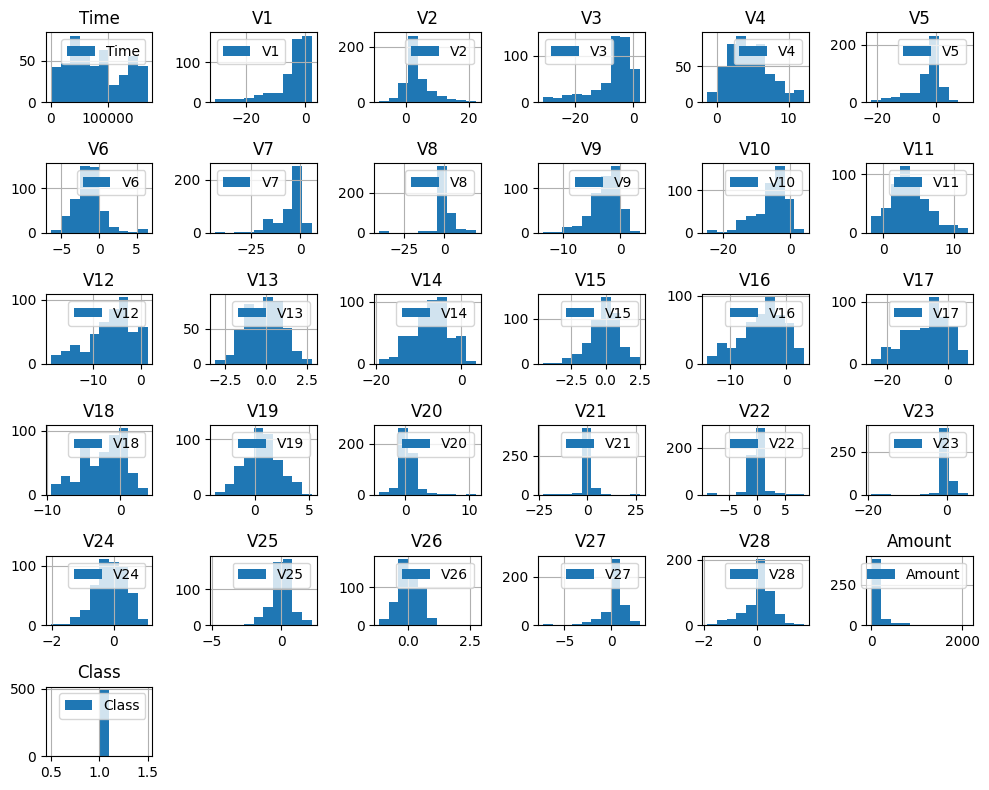

In [26]:
# Grouped histogram 
# Class 1 is fraudulent 0 is non-fraud

df_fraud.groupby('Class').hist(legend=True,figsize=(10,8))
plt.tight_layout()
plt.legend()

<Axes: title={'center': 'Fraud vs Non Detection'}, xlabel='Class'>

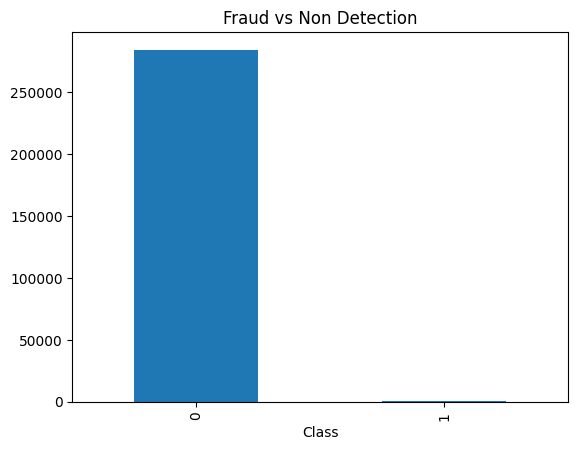

In [11]:
# bar plot for total counts of ea cateforical variable per column
df_fraud['Class'].value_counts().plot.bar(title='Fraud vs Non Detection')

In [25]:
# mean median mode
for col in df_fraud.columns:
    print(f'Column: {col}: mean: {df_fraud[col].mean()}, median: {df_fraud[col].median():.8f}, mode: {df_fraud[col].mode()}')
    print('-----'*10)

Column: Time: mean: 94813.85957508067, median: 84692.00000000, mode: 0    163152.0
Name: Time, dtype: float64
--------------------------------------------------
Column: V1: mean: 1.1751608993193201e-15, median: 0.01810880, mode: 0    1.245674
1    2.055797
Name: V1, dtype: float64
--------------------------------------------------
Column: V2: mean: 3.384974329561085e-16, median: 0.06548556, mode: 0   -0.326668
1    0.166975
Name: V2, dtype: float64
--------------------------------------------------
Column: V3: mean: -1.379536707896593e-15, median: 0.17984634, mode: 0   -2.752041
1    0.488306
Name: V3, dtype: float64
--------------------------------------------------
Column: V4: mean: 2.094852037917049e-15, median: -0.01984653, mode: 0   -0.842316
1    0.635322
Name: V4, dtype: float64
--------------------------------------------------
Column: V5: mean: 1.0218790428863653e-15, median: -0.05433583, mode: 0   -0.562777
1    2.463072
Name: V5, dtype: float64
------------------------------

In [ ]:
# Conclusion
'''
Data for most categories have normal distributions though Time is bimodal. When grouped by class ditributions normalize more. A few features have some outliers like V5 and V7.
Histograms do not have wide distributions with largest range being about 100.
Since columns V1-28 are hidden to protext user identities and sensitive feature they are hard to verbally relate. More analysis should still be done.

'''

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

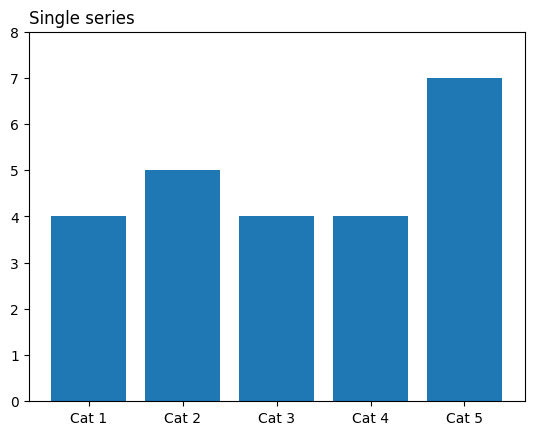

In [20]:
# Graph pg 54

labels = ['Cat 1', 'Cat 2','Cat 3','Cat 4','Cat 5']
amounts = [4,5,4,4,7]

plt.bar(labels,amounts)
plt.title('Single series',loc='left')
plt.ylim(0,8)
plt.show()